# 1. Construir CSVs con cada sujeto y todos sus mensajes unificados

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import json
import os
import csv

## Cargar CSVs originales

In [2]:
# conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Rutas CSVs y JSONs
base = "/content/drive/MyDrive/tfg/corpusMentalRiskES/processed/"
paths = {
    "ED": {
        "csv": base + "ED/gold/gold_label.csv",
        "json": base + "ED/data/"
    },
    "Depression": {
        "csv": base + "Depress/gold/gold_label.csv",
        "json": base + "Depress/data/"
    },
    "Anxiety": {
        "csv": base + "Anxiety/gold/gold_label.csv",
        "json": base + "Anxiety/data/"
    }
}

# Leer los csv
df_anx = pd.read_csv(paths["Anxiety"]["csv"], sep="\t")
df_dep = pd.read_csv(paths["Depression"]["csv"], sep="\t")
df_ed = pd.read_csv(paths["ED"]["csv"], sep="\t")

## Generar DataFrames con mensajes unificados

In [4]:
def cargar_mensajes_usuarios(ruta_json_folder):
    """
    Devuelve un diccionario {user_id: [lista_de_mensajes]}
    a partir de los .json del trastorno.
    """
    mensajes = {}
    for filename in os.listdir(ruta_json_folder):
        if filename.endswith(".json"):
            user_id = filename.replace(".json", "")
            with open(os.path.join(ruta_json_folder, filename), "r", encoding="utf-8") as f:
                # Lista de diccionarios
                data = json.load(f)
                # Lista de mensajes no vacíos: tomamos m["message"] y descartamos textos vacíos o espacios
                textos = [m["message"] for m in data if m.get("message", "").strip() != ""]
                mensajes[user_id] = textos
    return mensajes

def preparar_dataframe_trastorno(df_labels, ruta_json_folder):
    """
    Construye un DataFrame con columnas:
    user_id, texto, bs
    """
    mensajes_por_usuario = cargar_mensajes_usuarios(ruta_json_folder)

    filas = []
    for _, row in df_labels.iterrows():
        user_id = str(row["nick"])
        bs = int(row["bs"])

        if user_id not in mensajes_por_usuario:
            continue  # por si hay algún usuario sin json

        # Obtener mensajes de cada usuario y unirlos
        msgs = mensajes_por_usuario[user_id]
        texto = "\n".join(msgs).strip()

        filas.append({
            "user_id": user_id,
            "texto": texto,
            "bs": bs
        })

    df_final = pd.DataFrame(filas)
    return df_final

In [ ]:
df_anx_final = preparar_dataframe_trastorno(df_anx, paths["Anxiety"]["json"])
df_dep_final = preparar_dataframe_trastorno(df_dep, paths["Depression"]["json"])
df_ed_final = preparar_dataframe_trastorno(df_ed, paths["ED"]["json"])

display(df_anx_final)
print("\n")
display(df_dep_final)
print("\n")
display(df_ed_final)

# 2. Conjuntos para clasificación binaria

## 2.1. División train/val/test para BERT

Para entrenar y evaluar el modelo BERT, es necesario dividir el dataset en tres subconjuntos:

* **Entrenamiento** (70%)
* **Validación** (15%)
* **Test** (15%)

El conjunto de entrenamiento se utiliza para ajustar los pesos del modelo, el de validación para seleccionar hiperparámetros y evitar sobreajuste, y el de test para evaluar el rendimiento final.

Dado que el dataset está desbalanceado (especialmente en el caso del trastorno de ansiedad), la división se realiza mediante **estratificación**, utilizando la etiqueta bs como variable de estratificación. Esto asegura que la proporción entre las clases control y suffer se mantenga de forma similar en los tres subconjuntos.

La división se efectúa en dos pasos:
1.   Separar train del 30% restante.
2.   Dividir ese 30% en validación y test manteniendo también la estratificación.

In [ ]:
from sklearn.model_selection import train_test_split

def dividir_dataset(df, test_size=0.15, val_size=0.15, random_state=42):
    """
    Divide el dataset en train, val y test asegurando que la proporción
    entre clases (estratificación) se mantiene en cada subconjunto.
    """

    # 1. Train vs (Val + Test)
    df_train, df_temp = train_test_split(
        df,
        test_size = test_size + val_size,    # 0.30
        stratify = df["bs"],                 # mantiene proporción de clases
        random_state = random_state
    )

    # 2. Proporción val dentro del temporal (val + test)
    val_ratio = val_size / (test_size + val_size)

    # 3. Dividir temp → val y test
    df_val, df_test = train_test_split(
        df_temp,
        test_size = 1 - val_ratio,           # 0.5 (equivalente a 15% y 15%)
        stratify = df_temp["bs"],            # estratificación de nuevo
        random_state = random_state
    )

    return df_train, df_val, df_test

# Aplicar a cada trastorno
anx_train, anx_val, anx_test = dividir_dataset(df_anx_final)
dep_train, dep_val, dep_test = dividir_dataset(df_dep_final)
ed_train,  ed_val,  ed_test  = dividir_dataset(df_ed_final)

### Comprobar que los splits se hayan realizado correctamente manteniendo las distribuciones originales

In [ ]:
def imprimir_distribucion(df, nombre):
    print(f"\nDistribución de clases en {nombre}:")
    print(df["bs"].value_counts(normalize=False))      # valores absolutos
    print(df["bs"].value_counts(normalize=True).round(3))  # proporciones

imprimir_distribucion(anx_train, "Anxiety - Train")
imprimir_distribucion(anx_val,   "Anxiety - Validation")
imprimir_distribucion(anx_test,  "Anxiety - Test")

imprimir_distribucion(dep_train, "Depression - Train")
imprimir_distribucion(dep_val,   "Depression - Validation")
imprimir_distribucion(dep_test,  "Depression - Test")

imprimir_distribucion(ed_train, "ED - Train")
imprimir_distribucion(ed_val,   "ED - Validation")
imprimir_distribucion(ed_test,  "ED - Test")


Distribución de clases en Anxiety - Train:
bs
1    310
0     40
Name: count, dtype: int64
bs
1    0.886
0    0.114
Name: proportion, dtype: float64

Distribución de clases en Anxiety - Validation:
bs
1    67
0     8
Name: count, dtype: int64
bs
1    0.893
0    0.107
Name: proportion, dtype: float64

Distribución de clases en Anxiety - Test:
bs
1    66
0     9
Name: count, dtype: int64
bs
1    0.88
0    0.12
Name: proportion, dtype: float64

Distribución de clases en Depression - Train:
bs
1    233
0    116
Name: count, dtype: int64
bs
1    0.668
0    0.332
Name: proportion, dtype: float64

Distribución de clases en Depression - Validation:
bs
1    50
0    25
Name: count, dtype: int64
bs
1    0.667
0    0.333
Name: proportion, dtype: float64

Distribución de clases en Depression - Test:
bs
1    50
0    25
Name: count, dtype: int64
bs
1    0.667
0    0.333
Name: proportion, dtype: float64

Distribución de clases en ED - Train:
bs
0    134
1    100
Name: count, dtype: int64
bs
0    0.573

### Guardar los splits en CSVs

In [ ]:
output_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/BERT/"
os.makedirs(output_path, exist_ok=True)

anx_train.to_csv(output_path + "anxiety_train.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
anx_val.to_csv(output_path + "anxiety_val.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
anx_test.to_csv(output_path + "anxiety_test.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

dep_train.to_csv(output_path + "depression_train.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
dep_val.to_csv(output_path + "depression_val.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
dep_test.to_csv(output_path + "depression_test.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

ed_train.to_csv(output_path + "ed_train.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
ed_val.to_csv(output_path + "ed_val.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
ed_test.to_csv(output_path + "ed_test.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

## 2.2. Conjunto de evaluación para LLMs

En el caso de los LLMs no es necesario tener conjuntos train y val, ya que no hay entrenamiento. Por ello, se empleará como conjunto de evaluación el dataset completo.

Pero **en lugar de la versión *processed* del dataset se usará la versión *raw***, que incluye emojis que sí aceptan los LLMs.

In [ ]:
# Rutas CSVs y JSONs de la versión raw
base_raw = "/content/drive/MyDrive/tfg/corpusMentalRiskES/raw/"
paths_raw = {
    "ED": {
        "csv": base_raw + "ED/gold/gold_label.csv",
        "json": base_raw + "ED/data/"
    },
    "Depression": {
        "csv": base_raw + "Depress/gold/gold_label.csv",
        "json": base_raw + "Depress/data/"
    },
    "Anxiety": {
        "csv": base_raw + "Anxiety/gold/gold_label.csv",
        "json": base_raw + "Anxiety/data/"
    }
}

# Leer los csv
df_raw_anx = pd.read_csv(paths_raw["Anxiety"]["csv"], sep="\t")
df_raw_dep = pd.read_csv(paths_raw["Depression"]["csv"], sep="\t")
df_raw_ed = pd.read_csv(paths_raw["ED"]["csv"], sep="\t")

In [ ]:
# Generar dataframes con los mensajes unificados
df_raw_anx_final = preparar_dataframe_trastorno(df_raw_anx, paths_raw["Anxiety"]["json"])
df_raw_dep_final = preparar_dataframe_trastorno(df_raw_dep, paths_raw["Depression"]["json"])
df_raw_ed_final = preparar_dataframe_trastorno(df_raw_ed, paths_raw["ED"]["json"])

# display(df_raw_anx_final)
# print("\n")
# display(df_raw_dep_final)
# print("\n")
# display(df_raw_ed_final)

In [ ]:
# Guardar los splits en CSV
output_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/"
os.makedirs(output_path, exist_ok=True)

df_raw_anx_final.to_csv(output_path + "anxiety_llm.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
df_raw_dep_final.to_csv(output_path + "depression_llm.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
df_raw_ed_final.to_csv(output_path + "ed_llm.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

### 2.2.1. Subconjuntos para Tara@5

Para evaluar la estabilidad de las predicciones de los LLMs se utilizará la métrica TARa@5 (Total Agreement Rate), que mide el grado de acuerdo entre varias ejecuciones del modelo con la misma entrada. Con el fin de reducir el coste computacional, en lugar de repetir la inferencia sobre todo el dataset se selecciona un subconjunto estratificado de ejemplos.

La selección se realiza mediante muestreo estratificado, manteniendo la proporción de clases del dataset original. En clasificación binaria se extraen 100 ejemplos por trastorno, mientras que en el caso multiclase se seleccionan 250 ejemplos del conjunto completo. Cada uno de estos ejemplos será evaluado cinco veces por cada modelo, lo que permitirá estimar la estabilidad de sus predicciones.

In [ ]:
base_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/"
df_raw_anx_final = pd.read_csv(base_path + "anxiety_llm.csv", sep=",")
df_raw_dep_final = pd.read_csv(base_path + "depression_llm.csv", sep=",")
df_raw_ed_final = pd.read_csv(base_path + "ed_llm.csv", sep=",")

In [ ]:
from sklearn.model_selection import train_test_split

def extraer_subconjunto(dataset, n, label_col):
  """
  Extrae un subconjunto estratificado de tamaño n a partir de un dataset.
  """
  subconjunto, _ = train_test_split(
      dataset,
      train_size=n,
      stratify=dataset[label_col],
      random_state=42
  )

  return subconjunto

In [ ]:
df_anx_tara5 = extraer_subconjunto(df_raw_anx_final, 100, "bs")
df_dep_tara5 = extraer_subconjunto(df_raw_dep_final, 100, "bs")
df_ed_tara5 = extraer_subconjunto(df_raw_ed_final, 100, "bs")

In [ ]:
# Guardar los subconjuntos en CSV
output_path_tara5 = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/tara5"
os.makedirs(output_path_tara5, exist_ok=True)

df_anx_tara5.to_csv(output_path_tara5 + "anxiety_llm_tara5.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
df_dep_tara5.to_csv(output_path_tara5 + "depression_llm_tara5.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
df_ed_tara5.to_csv(output_path_tara5 + "ed_llm_tara5.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

# 3. Conjuntos para clasificación multiclase

En clasificació multiclase, en vez de entrenar un modelo por trastorno (ansiedad / depresión / ED), como en la clasificación binaria, ahora queremos un modelo que detecte cuál de los 3 trastornos sufre el usuario.

Para ello unificamos los dataframes de clasificación binaria en uno solo donde cada usuario pertenece a exactamente una clase. Por tanto, el dataset multiclase quedará así:

* Todos los usuarios de Anxiety → clase = 1
* Todos los usuarios de Depression → clase = 2
* Todos los usuarios de ED → clase = 3
* Los usuarios control dentro de cada carpeta siguen siendo “control”
→ clase = 0

In [6]:
# Copia para no modificar los originales
df_anx_mc = df_anx_final.copy()
df_dep_mc = df_dep_final.copy()
df_ed_mc = df_ed_final.copy()

# Añadir columna con trastorno
df_anx_mc["trastorno"] = "anxiety"
df_dep_mc["trastorno"] = "depression"
df_ed_mc["trastorno"] = "ed"

# Crear la etiqueta multiclase
def asignar_etiqueta(row):
    if row["bs"] == 0:
        return 0  # control
    if row["trastorno"] == "anxiety":
        return 1
    if row["trastorno"] == "depression":
        return 2
    if row["trastorno"] == "ed":
        return 3

df_anx_mc["label_mc"] = df_anx_mc.apply(asignar_etiqueta, axis=1)
df_dep_mc["label_mc"] = df_dep_mc.apply(asignar_etiqueta, axis=1)
df_ed_mc["label_mc"] = df_ed_mc.apply(asignar_etiqueta, axis=1)

# Concatenar los tres dataset
df_multi = pd.concat([df_anx_mc, df_dep_mc, df_ed_mc], ignore_index=True)

print(df_multi.label_mc.value_counts())

label_mc
1    443
0    415
2    333
3    143
Name: count, dtype: int64


El conjunto multiclase presenta un nivel moderado de desbalance entre categorías. La clase más numerosa es ansiedad (443 usuarios), seguida de control (415), depresión (333) y, finalmente, trastornos alimentarios (143), que constituye la clase minoritaria. Aunque el desbalance no es extremo, sí puede influir en el entrenamiento del modelo BERT multiclase, favoreciendo el aprendizaje de las clases más frecuentes y dificultando la detección de ED. Para mitigar este efecto, será importante emplear métricas equilibradas como el F1-macro y considerar técnicas como el uso de pesos de clase durante el entrenamiento.

## 3.1. División train/val/test para BERT

In [ ]:
# División estratificada
train_mc, temp_mc = train_test_split(
    df_multi,
    test_size=0.30,
    stratify=df_multi["label_mc"],
    random_state=42
)

val_mc, test_mc = train_test_split(
    temp_mc,
    test_size=0.50,
    stratify=temp_mc["label_mc"],
    random_state=42
)

In [ ]:
# Guardar en CSV
output_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/BERT/"
os.makedirs(output_path, exist_ok=True)
train_mc.to_csv(output_path + "multiclass_train.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
val_mc.to_csv(output_path + "multiclass_val.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
test_mc.to_csv(output_path + "multiclass_test.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

## 3.2. Conjunto de evaluación para LLMs

In [ ]:
# Copias RAW
df_raw_anx_mc = df_raw_anx_final.copy()
df_raw_dep_mc = df_raw_dep_final.copy()
df_raw_ed_mc  = df_raw_ed_final.copy()

# Añadir trastorno
df_raw_anx_mc["trastorno"] = "anxiety"
df_raw_dep_mc["trastorno"] = "depression"
df_raw_ed_mc["trastorno"]  = "ed"

# Etiqueta multiclase
def asignar_etiqueta(row):
    if row["bs"] == 0:
        return 0
    if row["trastorno"] == "anxiety":
        return 1
    if row["trastorno"] == "depression":
        return 2
    if row["trastorno"] == "ed":
        return 3

for df in [df_raw_anx_mc, df_raw_dep_mc, df_raw_ed_mc]:
    df["label_mc"] = df.apply(asignar_etiqueta, axis=1)

# Dataset multiclase LLM (RAW)
df_raw_multi_llm = pd.concat([df_raw_anx_mc, df_raw_dep_mc, df_raw_ed_mc], ignore_index=True)

In [ ]:
# Guardar el dataset completo adaptado a clasificacion multiclase
output_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/"
os.makedirs(output_path, exist_ok=True)

df_raw_multi_llm.to_csv(output_path + "multiclass_llm.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

### 3.2.1. Subconjuntos para Tara@5

In [ ]:
base_path = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/"
df_raw_multi_llm = pd.read_csv(base_path + "multiclass_llm.csv", sep=",")

In [ ]:
df_multi_tara5 = extraer_subconjunto(df_raw_multi_llm, 250, "label_mc")

In [ ]:
# Guardar los subconjuntos en CSV
output_path_tara5 = "/content/drive/MyDrive/tfg/corpusMentalRiskES/splits/LLM/tara5/"
os.makedirs(output_path_tara5, exist_ok=True)

df_multi_tara5.to_csv(output_path_tara5 + "multiclass_llm_tara5.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

# 4. Análisis adicionales sobre los conjuntos preparados

## 4.1. Análisis adicional de número de tokens para BERT

BERT tiene un límite de 512 tokens, por lo que es necesario ver si los textos de cada usuario superan este límite:





In [9]:
# Cargar el tokenizador de BERT
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [15]:
# Calcular los tokens de TODOS los textos del dataset
def contar_tokens(df, tokenizer):
    longitudes = []
    for texto in df["texto"]:
        tokens = tokenizer.encode(texto, add_special_tokens=True)
        longitudes.append(len(tokens))
    return longitudes

tokens_anx = contar_tokens(df_anx_final, tokenizer)
tokens_dep = contar_tokens(df_dep_final, tokenizer)
tokens_ed  = contar_tokens(df_ed_final, tokenizer)
tokens_multi = contar_tokens(df_multi, tokenizer)

# Ver estadísticas generales
print(f"{'Categoría':<12} {'Media tokens':>15} {'Máx tokens':>15}")
print("-" * 45)

print(f"{'Ansiedad':<12} {np.mean(tokens_anx):>15.2f} {np.max(tokens_anx):>15}")
print(f"{'Depresión':<12} {np.mean(tokens_dep):>15.2f} {np.max(tokens_dep):>15}")
print(f"{'ED':<12} {np.mean(tokens_ed):>15.2f} {np.max(tokens_ed):>15}")
print(f"{'Multiclase':<12} {np.mean(tokens_multi):>15.2f} {np.max(tokens_multi):>15}")

Categoría       Media tokens      Máx tokens
---------------------------------------------
Ansiedad             1042.98            6134
Depresión             820.24            6457
ED                    799.53           12754
Multiclase            898.52           12754


**Problema**: Muchos de los textos del dataset superan el límite máximo de 512 tokens que puede procesar BERT-base. Esto obliga a tomar una decisión sobre cómo manejar secuencias largas.

**Opciones disponibles**:

* **Truncación durante la tokenización**: Solo se conservan los primeros 512 tokens de cada texto. Esta solución es sencilla y eficiente, pero puede implicar pérdida de información.
* **Uso de un modelo Transformer de tipo long-range**: Estos modelos pueden procesar miles de tokens, evitando la necesidad de truncar. No obstante, su entrenamiento es más costoso en términos computacionales.

**Decisión**: En este TFG se emplearán ambos enfoques:

* BERT-base con truncación a 512 tokens, y
* un modelo long-range capaz de procesar secuencias completas.

Esto permitirá evaluar hasta qué punto la truncación afecta al rendimiento y si realmente compensa utilizar modelos long-range, Longformer en concreto, que implican un mayor coste computacional.



## 4.2. Análisis exploratorio mediante embeddings + visualización

Antes de entrenar los modelos, puede ser útil analizar si los textos de las distintas clases presentan cierta separación semántica de forma natural. Para ello, se generan embeddings de cada texto utilizando un modelo de *sentence embeddings*, que transforma cada documento en un vector numérico que captura su significado semántico.

Posteriormente, estos embeddings se proyectan a un espacio bidimensional mediante técnicas de reducción de dimensionalidad como PCA y t-SNE. Esto permite visualizar si los ejemplos tienden a formar clusters diferenciados o si existe un fuerte solapamiento entre clases, lo que ayuda a interpretar la dificultad real de la tarea de clasificación.

In [7]:
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

### 4.2.1. Generar embeddings

In [8]:
# Cargar modelo de embeddings
model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embedder = SentenceTransformer(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
# Seleccionar dataset multiclase
sample_df = df_multi.copy()

texts = sample_df["texto"].tolist()
labels = sample_df["label_mc"].tolist()

# Generar embeddings
embeddings = embedder.encode(
    texts,
    show_progress_bar=True,
)

print("Shape embeddings:", embeddings.shape)

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

Shape embeddings: (1334, 768)


### 4.2.2. PCA

In [10]:
# Reducción
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

print("Varianza explicada PCA:",
      pca.explained_variance_ratio_.sum())

Varianza explicada PCA: 0.18542087


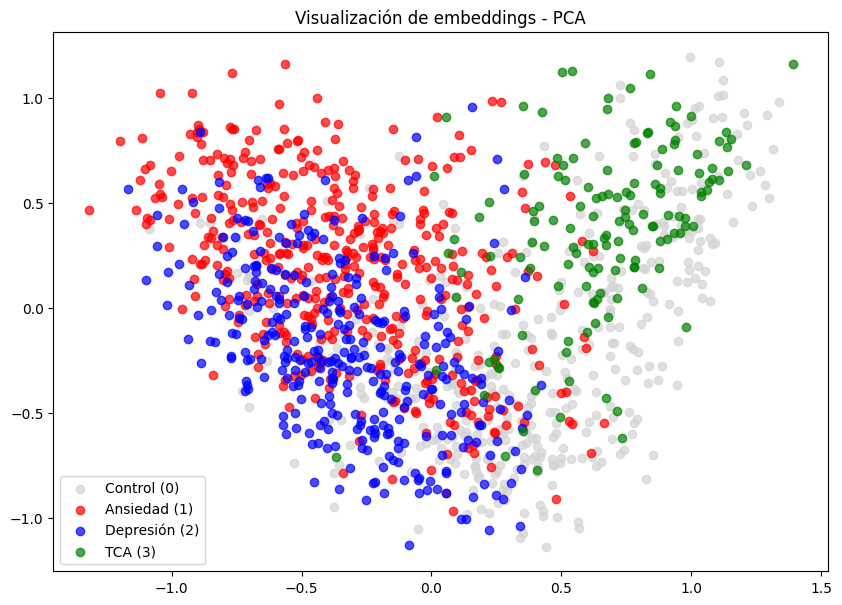

In [24]:
# ------------------------------------------------------------
# Mapeo de etiquetas + colores personalizados
# ------------------------------------------------------------
label_names = {
    0: "Control (0)",
    1: "Ansiedad (1)",
    2: "Depresión (2)",
    3: "TCA (3)"
}

label_colors = {
    0: "lightgray",   # Control
    1: "red",         # Ansiedad
    2: "blue",        # Depresión
    3: "green"        # TCA
}

# ------------------------------------------------------------
# Visualización PCA
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for clase in sorted(set(labels)):
    idx = [i for i, x in enumerate(labels) if x == clase]
    plt.scatter(
        embeddings_pca[idx, 0],
        embeddings_pca[idx, 1],
        label=label_names.get(clase, str(clase)),
        color=label_colors.get(clase, None),
        alpha=0.7
    )

plt.title("Visualización de embeddings - PCA")
plt.legend()
plt.show()

### 4.2.2. t-SNE

In [12]:
# Reducción
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

embeddings_tsne = tsne.fit_transform(embeddings)

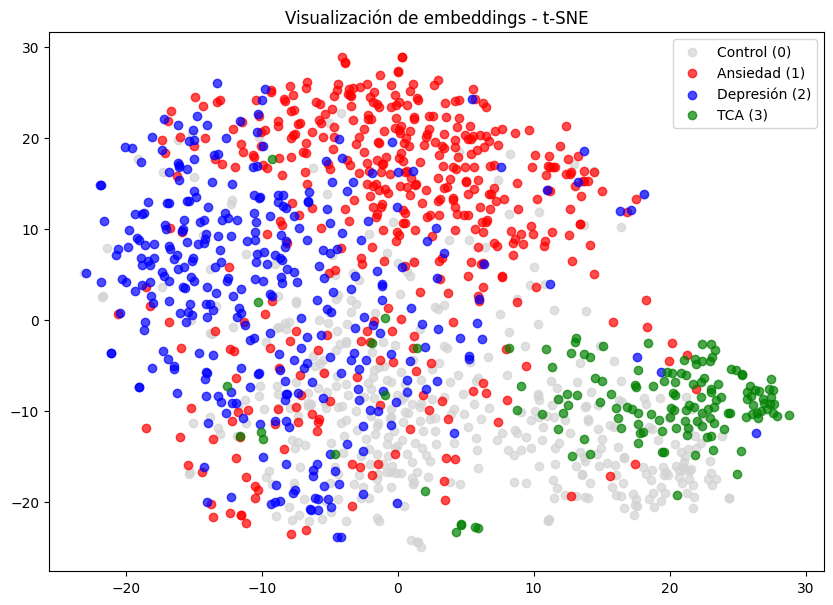

In [25]:
# ------------------------------------------------------------
# Visualización t-SNE
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

for clase in sorted(set(labels)):
    idx = [i for i, x in enumerate(labels) if x == clase]
    plt.scatter(
        embeddings_tsne[idx, 0],
        embeddings_tsne[idx, 1],
        label=label_names.get(clase, str(clase)),
        color=label_colors.get(clase, None),
        alpha=0.7
    )

plt.title("Visualización de embeddings - t-SNE")
plt.legend()
plt.show()

En la proyección mediante PCA se observa una estructura relativamente organizada, donde la clase TCA (verde) aparece más concentrada y desplazada hacia una región más diferenciada del espacio vectorial, lo que sugiere que sus patrones lingüísticos presentan mayor especificidad semántica. Por el contrario, ansiedad (rojo) y depresión (azul) muestran un solapamiento considerable, especialmente en la zona central e izquierda del gráfico, reflejando la proximidad conceptual y clínica entre ambos trastornos.

La visualización mediante t-SNE refuerza esta misma interpretación de forma más clara. TCA vuelve a formar un clúster más definido y separado, mientras que ansiedad y depresión continúan mostrando una fuerte superposición, lo que anticipa una mayor dificultad para diferenciarlas automáticamente. La clase control (gris) aparece distribuida entre distintas regiones del espacio, sin formar un clúster propio claramente delimitado, lo cual resulta coherente al tratarse de una categoría heterogénea que no responde a un único patrón lingüístico específico.

Este análisis confirma que la tarea de clasificación presenta una dificultad inherente derivada del propio solapamiento semántico entre clases, especialmente entre ansiedad y depresión. Asimismo, justifica que ciertos errores de clasificación observados posteriormente no dependan únicamente del modelo utilizado, sino también de la ambigüedad natural presente en los datos.